### Azure BlobServiceClient data Extraction

In [1]:
# Install required packages
!pip install azure-storage-blob pandas

In [8]:
# Import libraries
from io import StringIO 
from azure.storage.blob import BlobServiceClient
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
# Configure Azure Storage connection
account_name = "blobcontainerdiss"
account_key = 
container_name = "datablobdiss"
blob_name = "All_Countries.xlsx"

# Create connection string
connect_str = f"DefaultEndpointsProtocol=https;AccountName={account_name};AccountKey={account_key};EndpointSuffix=core.windows.net"

# Create BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(connect_str)
blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)


In [4]:

try:
    # Download blob content as a binary stream
    downloaded_blob = blob_client.download_blob()
    data_bytes = downloaded_blob.readall()

    # Use pandas to read the Excel file directly from the binary data
    df = pd.read_excel(io=data_bytes, engine='openpyxl')

    # Display the first few rows of the DataFrame
    print(df.head())

except Exception as e:
    print(f"An error occurred: {e}")

   Unnamed: 0 Country Constructor Veh_type   Version    Brand   Veh_Model  \
0       19346      DE     HYUNDAI       OS    E11B11  HYUNDAI  KONA KAUAI   
1       20219      DE  DAIMLER AG      451  ZZBAA40A    SMART  EQ FORFOUR   
2       20220      DE  DAIMLER AG      451  ZZBAA40A    SMART  EQ FORFOUR   
3       20223      DE  DAIMLER AG      451  ZZBAA40A    SMART  EQ FORFOUR   
4       20224      DE  DAIMLER AG      451  ZZBAA40C    SMART  EQ FORFOUR   

  Veh_Category  Kg_veh  Test_mass  ...  Fuel_mode  Engine_cm3  Power_KW  \
0           M1    1760     1892.0  ...          E           0     100.0   
1           M1    1200     1288.0  ...          E           0      41.0   
2           M1    1200     1288.0  ...          E           0      41.0   
3           M1    1200     1288.0  ...          E           0      41.0   
4           M1    1200     1282.0  ...          E           0      41.0   

   El_Consumpt_whkm Erwltp (g/km)  year  Fuel consumption  \
0             143.0      

In [5]:
# After loading data into DataFrame 'df'
print(f"Total rows fetched: {df.shape[0]}")

Total rows fetched: 1048575


In [10]:
from pyspark.sql import SparkSession
import io
try:
    # Assuming blob_client is already initialized and points to the correct blob
    # Download the Excel file content as bytes
    downloaded_blob = blob_client.download_blob()
    data_bytes = downloaded_blob.readall()
    
    # Read the Excel bytes into a pandas DataFrame using openpyxl engine
    df = pd.read_excel(io.BytesIO(data_bytes), engine='openpyxl')
    print("Pandas DataFrame preview:")
    print(df.head())
    
    # Initialize SparkSession (ensure Spark is installed and configured)
    spark = SparkSession.builder.appName("ExcelToPySpark").getOrCreate()
    
    # Convert pandas DataFrame to PySpark DataFrame
    spark_df = spark.createDataFrame(df)
    
    # Show first 5 rows of the PySpark DataFrame
    print("PySpark DataFrame preview:")
    spark_df.show(5)
    
    # Print the schema of the PySpark DataFrame
    spark_df.printSchema()

except Exception as e:
    print(f"An error occurred: {e}")

Pandas DataFrame preview:
   Unnamed: 0 Country Constructor Veh_type   Version    Brand   Veh_Model  \
0       19346      DE     HYUNDAI       OS    E11B11  HYUNDAI  KONA KAUAI   
1       20219      DE  DAIMLER AG      451  ZZBAA40A    SMART  EQ FORFOUR   
2       20220      DE  DAIMLER AG      451  ZZBAA40A    SMART  EQ FORFOUR   
3       20223      DE  DAIMLER AG      451  ZZBAA40A    SMART  EQ FORFOUR   
4       20224      DE  DAIMLER AG      451  ZZBAA40C    SMART  EQ FORFOUR   

  Veh_Category  Kg_veh  Test_mass  ...  Fuel_mode  Engine_cm3  Power_KW  \
0           M1    1760     1892.0  ...          E           0     100.0   
1           M1    1200     1288.0  ...          E           0      41.0   
2           M1    1200     1288.0  ...          E           0      41.0   
3           M1    1200     1288.0  ...          E           0      41.0   
4           M1    1200     1282.0  ...          E           0      41.0   

   El_Consumpt_whkm Erwltp (g/km)  year  Fuel consumption  \

In [11]:
# Display concise summary of the DataFrame including column data types and non-null counts
print("DataFrame Info:")
print(df.info())

# Display descriptive statistics for all columns, including categorical and numerical data
print("\nDescriptive Statistics (including all columns):")
print(df.describe(include='all').transpose())

# Display count of missing values for each column
print("\nMissing Values per Column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 25 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Unnamed: 0              1048575 non-null  int64  
 1   Country                 1048575 non-null  object 
 2   Constructor             1048575 non-null  object 
 3   Veh_type                1048575 non-null  object 
 4   Version                 1048575 non-null  object 
 5   Brand                   1048575 non-null  object 
 6   Veh_Model               1048575 non-null  object 
 7   Veh_Category            1048575 non-null  object 
 8   Kg_veh                  1048575 non-null  int64  
 9   Test_mass               1048575 non-null  float64
 10  CO2_wltp                1048575 non-null  float64
 11  Wheelbase_mm            1048575 non-null  float64
 12  Axle_width_steer_mm     1048575 non-null  float64
 13  Axle_width_other_mm     1048575 non-null 

### Postgresql Database connection required jar file 

In [12]:
!wget https://jdbc.postgresql.org/download/postgresql-42.7.5.jar -P /tmp


--2025-04-16 23:11:13--  https://jdbc.postgresql.org/download/postgresql-42.7.5.jar
Resolving jdbc.postgresql.org (jdbc.postgresql.org)... 72.32.157.228, 2001:4800:3e1:1::228
Connecting to jdbc.postgresql.org (jdbc.postgresql.org)|72.32.157.228|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1087908 (1.0M) [application/java-archive]
Saving to: ‘/tmp/postgresql-42.7.5.jar.1’

postgresql-42.7.5.j 100%[===================>]   1.04M  1.42MB/s    in 0.7s    

2025-04-16 23:11:14 (1.42 MB/s) - ‘/tmp/postgresql-42.7.5.jar.1’ saved [1087908/1087908]



In [13]:
# Specify the columns to convert to category dtype
categorical_cols = [
    'Country', 'Constructor', 'Veh_type', 'Version', 
    'Brand', 'Veh_Model', 'Veh_Category', 'Energy', 'Fuel_mode'
]

# Convert columns to category dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Convert 'year' column to integer (nullable Int64)
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

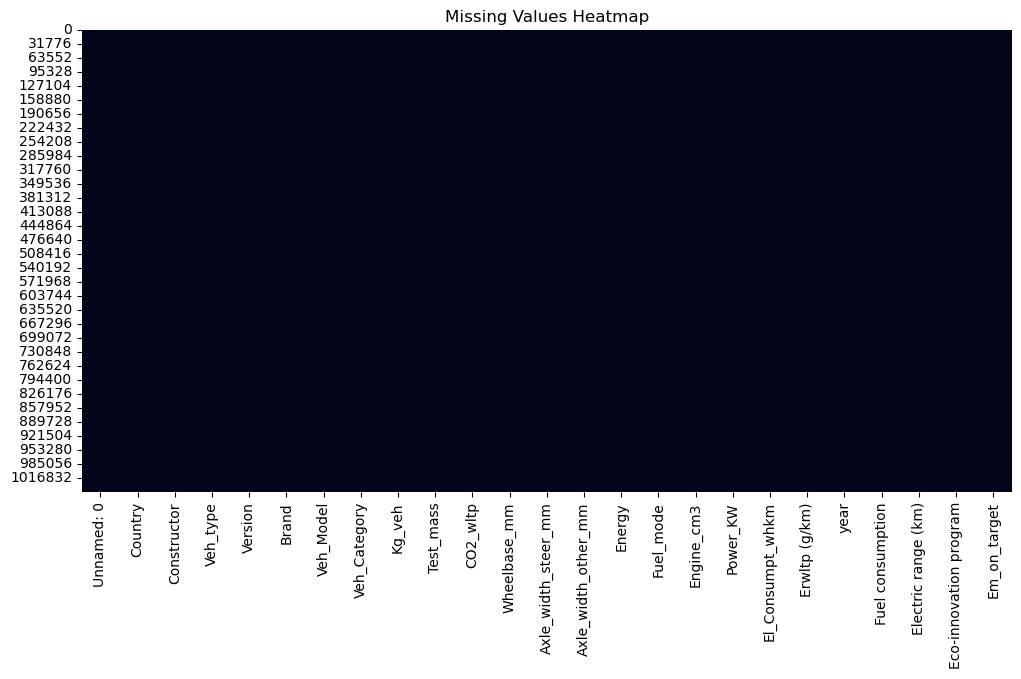

In [14]:
# Visualize missing data as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

# Impute missing values based on data type
for col in df.select_dtypes(include=['float', 'int']).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

### Data Preprocessing

In [15]:
# Columns to check for outliers
OUTLIER_COLUMNS = [
    'Kg_veh',
    'Test_mass',
    'CO2_wltp',
    'Power_KW',
    'El_Consumpt_whkm',
    'Electric range (km)'
]

def remove_exact_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove exact duplicate rows from the DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame.
        
    Returns:
        pd.DataFrame: Deduplicated DataFrame.
    """
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]
    return df

def remove_outliers(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Remove outliers from a specific column using the IQR method.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame.
        column (str): Column name to remove outliers from.
        
    Returns:
        pd.DataFrame: DataFrame with outliers removed for the specified column.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    original_count = df.shape[0]
    df = df[(df[column] >= lower) & (df[column] <= upper)]
    new_count = df.shape[0]
    return df

def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform basic EDA preprocessing: deduplication and outlier removal.
    
    Parameters:
        df (pd.DataFrame): Raw input DataFrame.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    df = remove_exact_duplicates(df)
    for col in OUTLIER_COLUMNS:
        if col in df.columns:
            df = remove_outliers(df, col)
    return df

# Usage
df = preprocess_data(df)

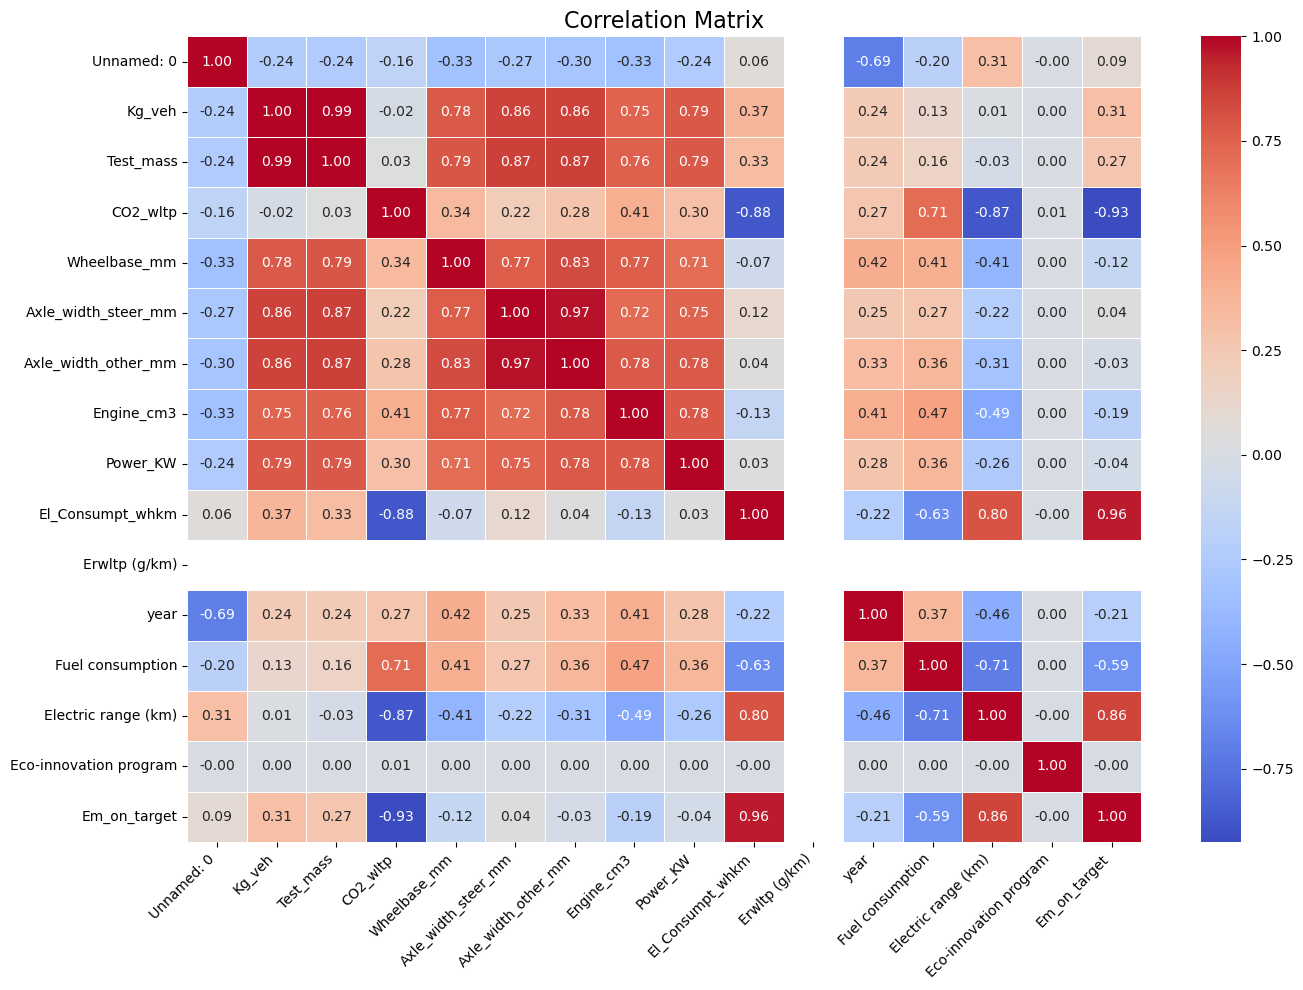

In [16]:
def plot_correlation_heatmap(df: pd.DataFrame, figsize: tuple = (14, 10)) -> None:
    """
    Plot a heatmap of the correlation matrix for numeric features in the DataFrame.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        figsize (tuple): Size of the matplotlib figure.
    """
    numeric_df = df.select_dtypes(include=['number'])
    corr = numeric_df.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Usage
plot_correlation_heatmap(df)

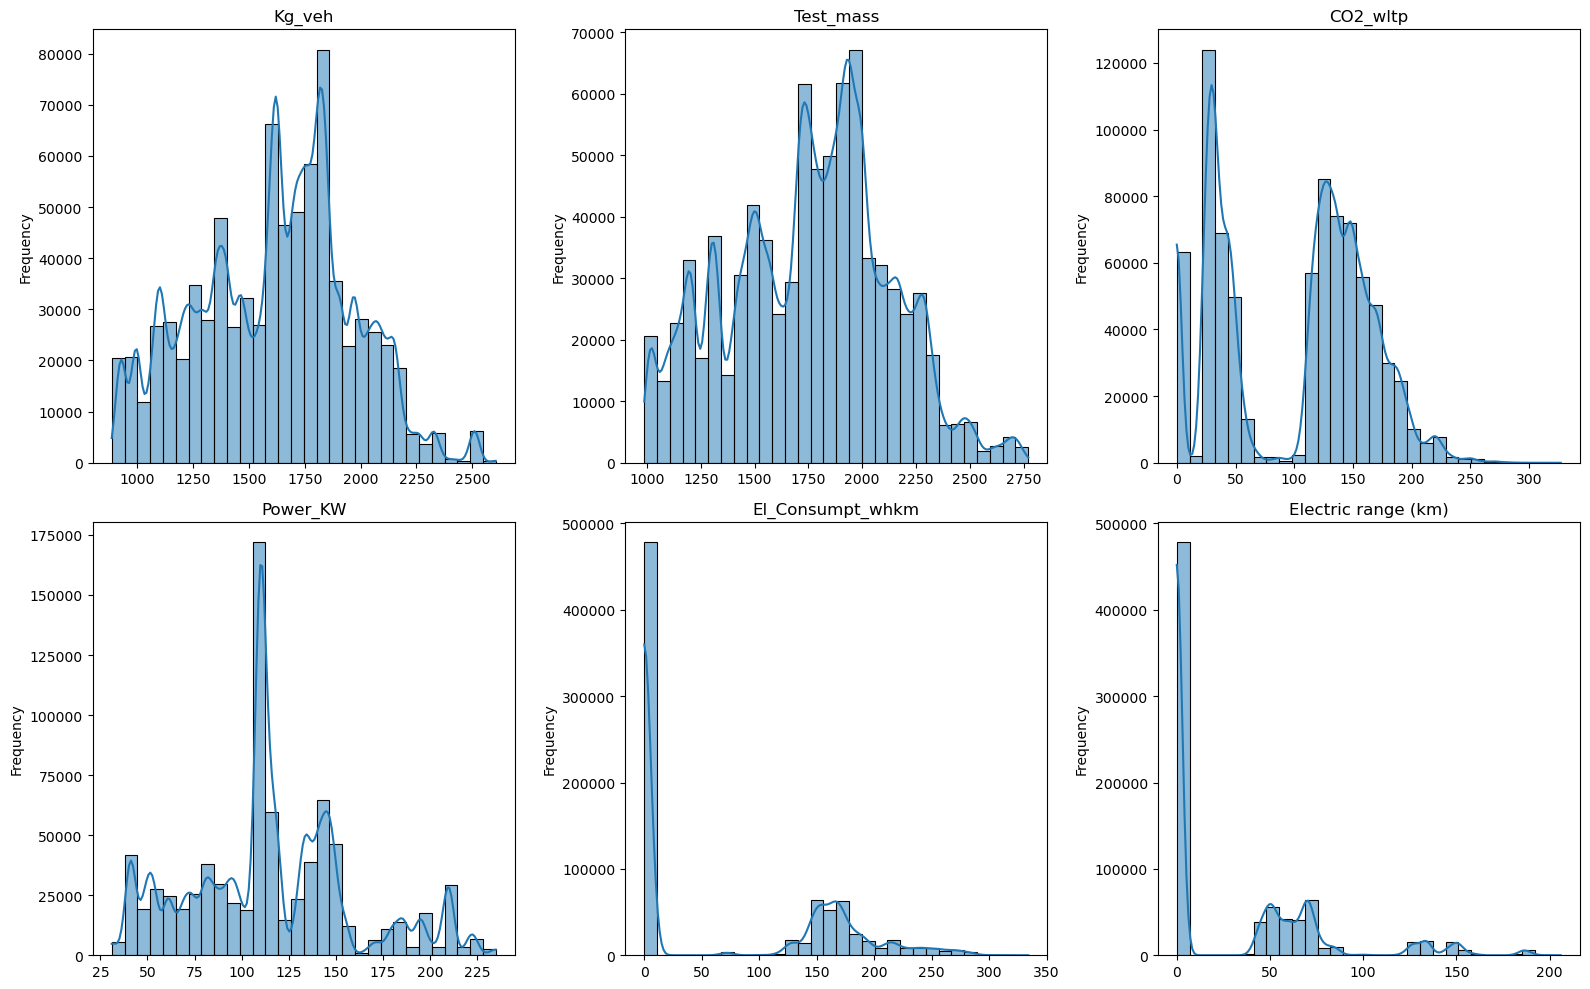

In [17]:
from typing import List

def plot_numeric_distributions(df: pd.DataFrame, columns: List[str], bins: int = 30, figsize: tuple = (16, 10)) -> None:
    """
    Plot histograms with KDE overlays for a list of numeric columns.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame.
        columns (List[str]): List of numeric column names to plot.
        bins (int): Number of histogram bins.
        figsize (tuple): Size of the overall figure.
    """
    num_cols = len(columns)
    rows = (num_cols + 2) // 3  # Up to 3 plots per row
    
    plt.figure(figsize=figsize)
    for i, col in enumerate(columns):
        if col not in df.columns:
            continue
        plt.subplot(rows, 3, i + 1)
        sns.histplot(df[col].dropna(), kde=True, bins=bins)
        plt.title(col)
        plt.xlabel('')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Usage
numeric_cols = ['Kg_veh', 'Test_mass', 'CO2_wltp', 'Power_KW', 'El_Consumpt_whkm', 'Electric range (km)']
plot_numeric_distributions(df, numeric_cols)

In [18]:
def display_unique_counts(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Display number of unique values for each specified column.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame.
        columns (List[str]): List of columns to evaluate.
    
    Returns:
        pd.DataFrame: Summary of unique value counts.
    """
    summary = pd.DataFrame({
        "Column": columns,
        "Unique Values": [df[col].nunique() for col in columns]
    }).sort_values("Unique Values", ascending=False).reset_index(drop=True)
    
    return summary

# Usage
display_unique_counts(df, numeric_cols)


,Column,Unique Values
0,Test_mass,1840
1,Kg_veh,965
2,CO2_wltp,311
3,El_Consumpt_whkm,235
4,Electric range (km),142
5,Power_KW,120


In [20]:
import logging
def convert_categoricals_to_string(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert all categorical columns in the DataFrame to string type.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame.
        
    Returns:
        pd.DataFrame: DataFrame with categorical columns as strings.
    """
    categorical_cols = df.select_dtypes(include=['category']).columns
    for col in categorical_cols:
        df[col] = df[col].astype(str)
        logging.info(f"Converted column '{col}' from 'category' to 'string'")
    return df

def save_dataframe_to_parquet(df: pd.DataFrame, path: str) -> None:
    """
    Save DataFrame to a Parquet file.
    
    Parameters:
        df (pd.DataFrame): DataFrame to save.
        path (str): Output file path.
    """
    df.to_parquet(path, index=False)
    logging.info(f"DataFrame saved to '{path}'")

# Usage
df = convert_categoricals_to_string(df)
save_dataframe_to_parquet(df, 'cleaned_data.parquet')

In [21]:
from pyspark.sql import SparkSession, DataFrame

def create_spark_session(app_name: str = "ParquetToPostgres", postgres_jar_path: str = "/usr/local/spark/jars/postgresql-42.7.5.jar") -> SparkSession:
    """
    Create and return a Spark session with PostgreSQL JDBC driver configured.
    
    Parameters:
        app_name (str): Spark application name.
        postgres_jar_path (str): Path to the PostgreSQL JDBC driver JAR file.
        
    Returns:
        SparkSession: Configured Spark session.
    """
    spark = SparkSession.builder \
        .appName(app_name) \
        .config("spark.jars", postgres_jar_path) \
        .getOrCreate()
    
    return spark

def load_parquet_to_spark(spark: SparkSession, path: str) -> DataFrame:
    """
    Load a Parquet file into a Spark DataFrame.
    
    Parameters:
        spark (SparkSession): Spark session.
        path (str): Path to the Parquet file.
        
    Returns:
        DataFrame: Loaded Spark DataFrame.
    """
    return spark.read.parquet(path)

# Usage
spark = create_spark_session()
spark_df = load_parquet_to_spark(spark, "cleaned_data.parquet")

In [22]:
def check_spark_schema_and_preview(df: DataFrame, num_rows: int = 5) -> None:
    """
    Print the schema of the Spark DataFrame and preview the first few rows.
    
    Parameters:
        df (DataFrame): Spark DataFrame to inspect.
        num_rows (int): Number of rows to display from the top of the DataFrame.
    """
    # Print schema
    print("DataFrame Schema:")
    df.printSchema()
    
    # Show the first few rows
    print(f"\nDisplaying first {num_rows} rows:")
    df.show(num_rows, truncate=False)

# Usage
check_spark_schema_and_preview(spark_df)

DataFrame Schema:
root
 |-- Unnamed: 0: long (nullable = true)
 |-- Country: string (nullable = true)
 |-- Constructor: string (nullable = true)
 |-- Veh_type: string (nullable = true)
 |-- Version: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Veh_Model: string (nullable = true)
 |-- Veh_Category: string (nullable = true)
 |-- Kg_veh: long (nullable = true)
 |-- Test_mass: double (nullable = true)
 |-- CO2_wltp: double (nullable = true)
 |-- Wheelbase_mm: double (nullable = true)
 |-- Axle_width_steer_mm: double (nullable = true)
 |-- Axle_width_other_mm: double (nullable = true)
 |-- Energy: string (nullable = true)
 |-- Fuel_mode: string (nullable = true)
 |-- Engine_cm3: long (nullable = true)
 |-- Power_KW: double (nullable = true)
 |-- El_Consumpt_whkm: double (nullable = true)
 |-- Erwltp (g/km): long (nullable = true)
 |-- year: long (nullable = true)
 |-- Fuel consumption: double (nullable = true)
 |-- Electric range (km): double (nullable = true)
 |-- Eco

### Data Transfer: Spark to PostgreSQL

This process loads the cleaned Parquet file into a **Spark DataFrame** and then transfers the data into a **PostgreSQL** database:

1. **Spark Session Creation**: A Spark session is initialized with the PostgreSQL JDBC driver.
2. **Parquet File Loading**: The cleaned dataset is read into a Spark DataFrame.
3. **Data Transfer to PostgreSQL**: The DataFrame is written to the PostgreSQL table using `jdbc` with error handling and logging for tracking progress.


In [29]:
import sys
import logging
from pyspark.sql import SparkSession, DataFrame

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def create_spark_session(app_name: str = "ParquetToPostgres",
                         postgres_jar_path: str = "/usr/local/spark/jars/postgresql-42.7.5.jar") -> SparkSession:
    return SparkSession.builder \
        .appName(app_name) \
        .config("spark.jars", postgres_jar_path) \
        .getOrCreate()

def load_parquet(spark: SparkSession, path: str) -> DataFrame:
    return spark.read.parquet(path)

def write_to_postgres(df: DataFrame, jdbc_url: str, table_name: str, properties: dict) -> None:
    try:
        logger.info("Starting data transfer to PostgreSQL...")
        df.write.jdbc(
            url=jdbc_url,
            table=table_name,
            mode="overwrite",  # Or "append"
            properties=properties
        )
        logger.info("Data successfully written to PostgreSQL.")
    except Exception as e:
        logger.error(f"Error writing to PostgreSQL: {e}")
        raise

def main():
    try:
        # Start Spark
        spark = create_spark_session()

        # Load data
        spark_df = load_parquet(spark, "cleaned_data.parquet")
        logger.info(f"Loaded {spark_df.count()} rows from Parquet.")

        # DB config
        jdbc_url = "jdbc:postgresql://host.docker.internal:5433/mydatabase"
        table_name = "country_data"
        properties = {
            "user": "postgres",
            "password": "Test@1234",  # Use environment variables in production
            "driver": "org.postgresql.Driver"
        }

        # Write to Postgres
        write_to_postgres(spark_df, jdbc_url, table_name, properties)

    except Exception as e:
        logger.exception("Something went wrong during the ETL process.")
        # Avoid sys.exit in Jupyter
    finally:
        spark.stop()
        logger.info("Spark session stopped.")


                                                                                                                                                                                                                                                                                                                                                                
main()


### Connect to PostgreSQL and Load Data

In this section, we:
1. **Install and import required libraries**: Ensuring `psycopg2` is installed for PostgreSQL connection.
2. **Create a connection engine**: Using SQLAlchemy to connect to PostgreSQL.
3. **Test the connection**: Ensuring successful connection before proceeding with data loading.
4. **Load the data**: If the table is found, it is loaded into a pandas DataFrame for further analysis.

In [30]:
import time
import pandas as pd
from sqlalchemy import create_engine, inspect
from urllib.parse import quote
import os

# Ensure psycopg2 is installed
try:
    import psycopg2
except ImportError:
    os.system('pip install psycopg2-binary')
    import psycopg2

# Database connection parameters (can be set via environment variables for security)
username = os.getenv('DB_USERNAME', 'postgres')  # Set via environment variable for security
password = quote(os.getenv('DB_PASSWORD', 'Test@1234'))  # Same for password
host = 'host.docker.internal'  # Can also be set via environment variable
port = '5433'
database = 'mydatabase'
table_name = 'country_data'

# Function to create PostgreSQL engine
def create_postgres_engine(username: str, password: str, host: str, port: str, database: str):
    return create_engine(f'postgresql://{username}:{password}@{host}:{port}/{database}')

# Function to test connection to the database
def test_connection(engine):
    try:
        start_time = time.time()
        with engine.connect() as connection:
            return True
    except Exception as e:
        return False

# Function to load table data into pandas DataFrame
def load_table_data(engine, table_name: str):
    try:
        # Get list of available tables
        inspector = inspect(engine)
        tables = inspector.get_table_names()
        
        if table_name in tables:
            df = pd.read_sql_table(table_name, con=engine)
            return df
        else:
            return None
    except Exception as e:
        return None

# Create PostgreSQL engine
engine = create_postgres_engine(username, password, host, port, database)

# Try connecting to the database
if test_connection(engine):
    # Load data if connection is successful
    df = load_table_data(engine, table_name)
else:
    # Attempt an alternative connection (localhost instead of docker internal host)
    alt_host = 'localhost' if host == 'host.docker.internal' else 'host.docker.internal'
    engine = create_postgres_engine(username, password, alt_host, port, database)
    
    if test_connection(engine):
        df = load_table_data(engine, table_name)


### CO2 Emission Discovery by Vehicle Type

In this visualization, we explore the relationship between **Energy Consumption** and **CO2 Emission** across different vehicle types.

#### Key Insights:
- **CO2 Emission vs Vehicle Type**: The bar plot represents the average CO2 emission (`CO2_wltp`) for different vehicle types (`Energy`).
- **Visualization Details**:
    - The **x-axis** represents the different vehicle types.
    - The **y-axis** shows the CO2 emission (in grams per kilometer, `g/km`).
    - The plot includes a title, axis labels, and rotated x-axis labels for better clarity.

This visualization can help us understand how different vehicle types contribute to CO2 emissions.


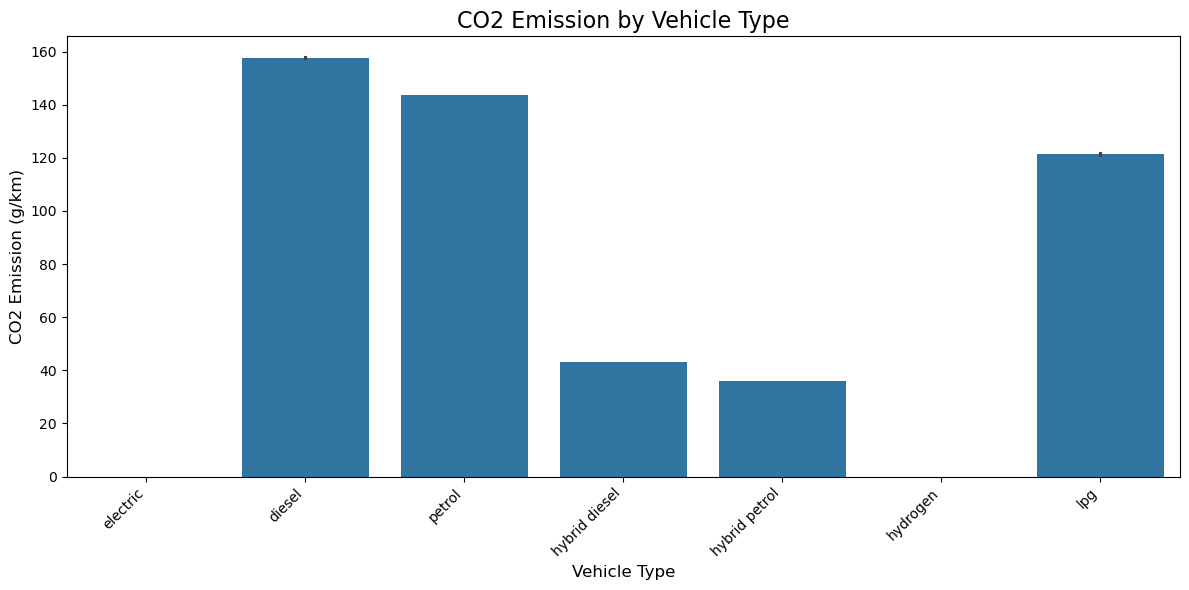

In [31]:
# Data processing - Initialize processed dataframe (in case further transformations are applied)
processed_df = df.copy()

# CO2 Emission Discovery Visualization
# Visualization 1: Energy Consumption by Vehicle Type vs CO2 Emission

plt.figure(figsize=(12, 6))
sns.barplot(x='Energy', y='CO2_wltp', data=processed_df)
plt.title('CO2 Emission by Vehicle Type', fontsize=16)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('CO2 Emission (g/km)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()

### Energy and Power Consumption by Vehicle Type

This scatter plot visualizes the relationship between **Energy** and **Power Consumption** across different vehicle types.

#### Key Insights:
- **Power Consumption vs Vehicle Type**: The scatter plot illustrates how vehicle types (`Energy`) relate to their **Power Consumption** (`Power_KW`).
- **Visualization Details**:
    - The **x-axis** represents the **vehicle type** (energy type).
    - The **y-axis** shows the **power consumption** (in kilowatts, `kW`).
    - The color hue represents **power consumption** to highlight differences across vehicle types.
    - The **palette 'viridis'** helps in distinguishing power levels with a color gradient.
    - Each point is outlined with a black edge for better visibility.


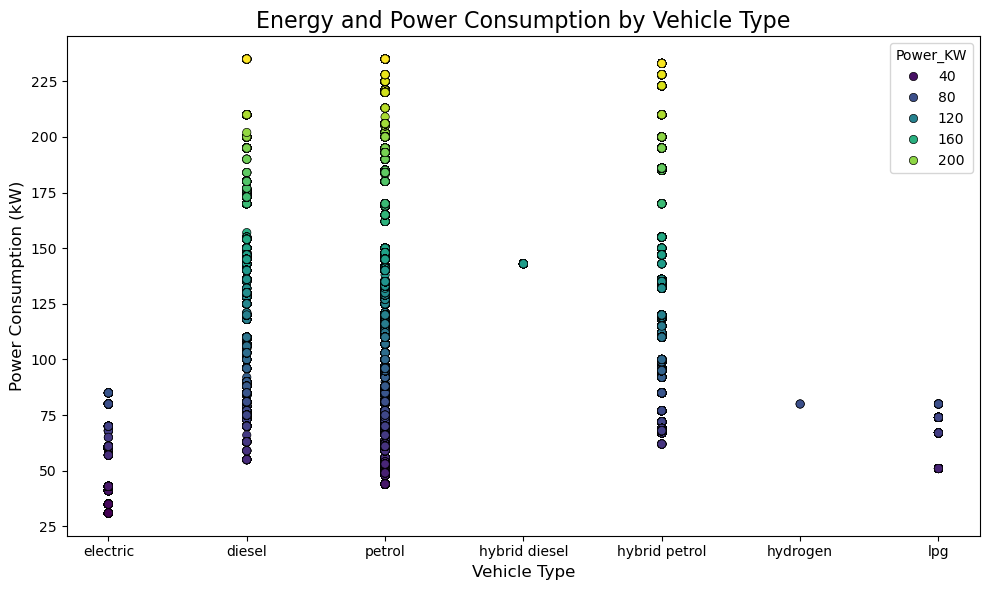

In [32]:
# Visualization 2: Energy and Power Consumption by Vehicle Type

plt.figure(figsize=(10, 6))

# Create scatter plot with 'Energy' and 'Power_KW' and color by 'Power_KW'
sns.scatterplot(x='Energy', y='Power_KW', 
                hue='Power_KW', palette='viridis', data=processed_df, edgecolor='black')

# Add title and labels with improved font size
plt.title('Energy and Power Consumption by Vehicle Type', fontsize=16)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Power Consumption (kW)', fontsize=12)

# Display plot
plt.tight_layout()  # Adjust the layout to avoid overlap
plt.show()


### Trend of Electric Vehicles by Year

This line chart visualizes the trend of **electric vehicles** over the years, providing insights into how the number of electric vehicles has evolved.

#### Key Insights:
- **Electric Vehicle Trend**: The plot shows the **count** of electric vehicles (`Energy == 'electric'`) per year.
- **Visualization Details**:
    - The **x-axis** represents the **year** of the vehicle.
    - The **y-axis** shows the **count of electric vehicles** for each year.
    - The **green line** with markers highlights the trend in a visually appealing way.
    - The **gridlines** help to trace the trend and identify key changes over time.
    
This chart can be used to analyze the growth or decline in the number of electric vehicles over the years.


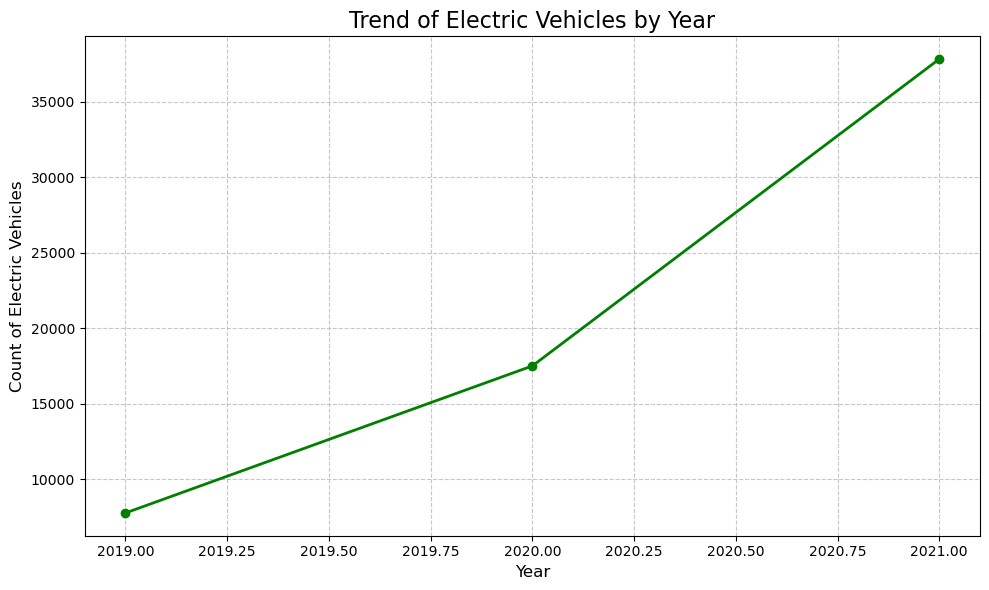

In [33]:
# Assuming df contains the loaded dataset
# Filter for electric vehicles
electric_vehicles = df[df['Energy'] == 'electric']

# Count electric vehicles by year
electric_by_year = electric_vehicles.groupby('year').size()

# Visualization: Line chart for trend of electric vehicles by year
plt.figure(figsize=(10, 6))

# Plot line chart with markers
electric_by_year.plot(kind='line', marker='o', color='green', linestyle='-', linewidth=2, markersize=6)

# Title and labels with improved font sizes
plt.title('Trend of Electric Vehicles by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count of Electric Vehicles', fontsize=12)

# Adding gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to avoid overlapping labels
plt.tight_layout()

# Display the plot
plt.show()


This notebook demonstrates various **data processing** and **visualization** techniques, specifically focusing on **CO2 emissions**, **energy consumption**, and **electric vehicle trends**.

#### 1. **Data Cleaning & Preprocessing**
- **Removing duplicates**: The first step involved removing any exact duplicates from the dataset using `drop_duplicates()`.
- **Outlier removal**: A custom function `remove_outliers()` was defined to remove outliers for several numerical columns based on the IQR (Interquartile Range) method. This step ensures that the analysis is not skewed by extreme values.
- **Converting categorical columns**: Categorical columns were converted to string type before saving the cleaned dataset to a Parquet file for better compatibility.

#### 2. **Exploratory Data Analysis (EDA)**
- **Correlation Matrix**: A correlation matrix was created to visualize relationships between numeric variables. The `seaborn` heatmap was used to display the correlation between variables like vehicle weight, power consumption, CO2 emissions, and more.
- **Distribution Plots**: Histograms and KDE plots were used to visualize the distribution of various numerical variables (e.g., power, weight, CO2 emissions). These plots provide insight into the spread and central tendency of each feature.

#### 3. **Database Operations**
- **Loading Data into PostgreSQL**: A connection to a PostgreSQL database was established using `SQLAlchemy` and `psycopg2`. The cleaned data was written to a PostgreSQL database.
- **Data Loading with SQLAlchemy**: The script also included steps to check for existing tables, load data from PostgreSQL into a Pandas DataFrame, and handle connection errors gracefully.

#### 4. **Refinements and Best Practices**
- **Code Modularization**: Functions were introduced for better code organization, such as separating connection handling and data loading into functions.
- **Error Handling & Logging**: Throughout the code, error handling was added to ensure robustness, and logging was used for better traceability of processes and potential issues.
- **Data Visualization Best Practices**: The code was optimized for visual clarity by improving plot styles, adding gridlines, and adjusting font sizes. Additionally, color palettes were chosen for better visual appeal and accessibility.

#### 5. **Data Visualization**
- **CO2 Emission by Vehicle Type**: A bar plot was created to visualize how CO2 emissions vary across different vehicle types. The `sns.barplot()` function was used to plot the relationship between `Energy` (vehicle type) and `CO2_wltp` (CO2 emissions).
- **Energy vs Power Consumption**: A scatter plot was created to explore the relationship between **energy type** and **power consumption** across vehicles. The `sns.scatterplot()` function was used, with color hues representing power consumption levels.
  
#### 6. **Electric Vehicle Trend Analysis**
- **Electric Vehicles Filter**: The dataset was filtered to exclude electric cars according to the `Energy` column.The dataset was then yearly classified to tally the number of electric vehicles per year.
- **Line Chart for Trend Visualization**: A line graph was developed to indicate how electric cars trend over time.Tracking the rise or fall in electric car adoption over time becomes possible with this.

### Conclusion
This notebook offers a well-rounded approach to **data processing**, **exploratory data analysis**, and **visualisation** for comprehending **CO2 emissions** and **electric vehicle trends**. It also provides **database operations** for storing and loading data from PostgreSQL. 